# Assignment 6: Data Scraping
```
Course: ENV 700 - Environmental Data Exploration
Author: Student Name
Date: Fall 2026
```

This notebook accompanies the Python lessons on **Data Scraping**. We'll be scraping data from the North Carolina Department of Water Quality (NC DWQ). 

## 1. Setup
* Import packages: `requests`, `BeautifulSoup` (from `bs4`), `pandas` (as `pd`), `seaborn` (as `sns`) and any other packages you wish to use. 
* Set your Seaborn theme's style, context, and any runtime configurations you wish

In [21]:
#Import packages
import pandas as pd

import requests
from bs4 import BeautifulSoup
import calendar

import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess


#Set Seaborn theme
sns.set_theme(style="darkgrid", context='notebook')

## 2. Scraping Water Supply Data 
We will be scraping data from the NC DEQs Local Water Supply Planning website, specifically the Durham's 2025 Municipal Local Water Supply Plan (LWSP): 
 * Navigate to https://www.ncwater.org/WUDC/app/LWSP/search.php
 * Set the year to 2025
 * Scroll down and select the LWSP link next to Durham Municipality. 
 * Note the web address: <https://www.ncwater.org/WUDC/app/LWSP/report.php?pwsid=03-32-010&year=2025>

---
### 2.1 Retrieve the website and parse it using BeautifulSoup

In [3]:
# 2.1 Retrieve the website and parse it using BeautifulSoup
url = requests.get('https://www.ncwater.org/WUDC/app/LWSP/report.php?pwsid=03-32-010&year=2025')

parsed = BeautifulSoup(url.text, 'html.parser')

### 2.2 The data we want to collect are listed below:

* From the **1. System Information** section:
    - Water system name
    - Contact Person
    - Ownership
 
* From the **3. Water Supply Sources** section:
    - Maximum Day Use (MGD) - for each month

In the code chunk below scrape these values, assigning them to four separate variables.  
>HINT: The first value should be "`Durham`", the second "`Kieu Tran`", the third "`Municipality`", and the last should be a vector of 12 numeric values (represented as strings)".

In [4]:
# 2.2 Scrape the data into variables
name_one = parsed.select_one('td tr:nth-child(1) td:nth-child(2)').get_text(strip=True) 

contact_one = parsed.select_one('tr:nth-child(4) td:nth-child(2)').get_text(strip=True) 

ownership_one = parsed.select_one('tr:nth-child(2) td:nth-child(4)').get_text(strip=True) 

MGD_node = parsed.select('th~ td+ td')
MGD_one = [node.get_text(strip=True) for node in MGD_node]

print(name_one)
print(ownership_one)
print(contact_one)
print(MGD_one)


Durham
Municipality
Kieu Tran
['40.2400', '37.3800', '37.9100', '33.8100', '36.8400', '36.9000', '36.5300', '38.0400', '33.8000', '37.9500', '35.2000', '32.2000']


### 2.3 Construct a dataframe from the scraped data
Convert your scraped data into a dataframe. 
* This dataframe should have a column for each of the 4 variables scraped and a row for the month corresponding to the withdrawal data. 
* Note that you won't likely be able to scrape max water usage data in chronological order.
* Include columns for the month and year the data were collected. 
* Sort the data on year and month.
* Construct a datetime column from the year and month, assuming the day of the month will be the first. 

>🔥**TIP**: : To construct a list from a repeated set of values, use this approach:
>```python
>years_x6 = [2025] * 6
>print(years_x6)
>```

>🔥**TIP**: To construct a datetime column when you just the year and month, you can use the following:
>```python
>df['Date'] = pd.to_datetime({
>    "year": df['Year'],
>    "month": df['Month'],
>    "day": 1
>})
>```

In [32]:
# 2.3 Construct the dataframe from scraped data
months = [1,5,9,2,6,10,3,7,11,4,8,12]

df_2025 = pd.DataFrame({
    "water system name" : name_one,
    "ownership" : ownership_one,
    'contact' : contact_one,
    'MGD': MGD_one,
    'month' : months,
    'year' : 2025
}).sort_values(by = 'month')

df_2025['date'] = pd.to_datetime({
    'year' : df_2025['year'],
    'month' : df_2025['month'],
     'day' : 1 })
df_2025['month_abb'] = pd.Categorical(
    values =df_2025['date'].dt.month_name().str[:3],
    categories =calendar.month_abbr[1:]
)
df_2025['MGD'] = df_2025['MGD'].astype('float')

df_2025.info()

df_2025.head()

<class 'pandas.DataFrame'>
Index: 12 entries, 0 to 11
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   water system name  12 non-null     str           
 1   ownership          12 non-null     str           
 2   contact            12 non-null     str           
 3   MGD                12 non-null     float64       
 4   month              12 non-null     int64         
 5   year               12 non-null     int64         
 6   date               12 non-null     datetime64[us]
 7   month_abb          12 non-null     category      
dtypes: category(1), datetime64[us](1), float64(1), int64(2), str(3)
memory usage: 1.1 KB


,water system name,ownership,contact,MGD,month,year,date,month_abb
0,Durham,Municipality,Kieu Tran,40.24,1,2025,2025-01-01,Jan
3,Durham,Municipality,Kieu Tran,33.81,2,2025,2025-02-01,Feb
6,Durham,Municipality,Kieu Tran,36.53,3,2025,2025-03-01,Mar
9,Durham,Municipality,Kieu Tran,37.95,4,2025,2025-04-01,Apr
1,Durham,Municipality,Kieu Tran,37.38,5,2025,2025-05-01,May


### 2.4 Plot the data
* Create a line plot of the maximum daily withdrawals across the months for 2025
* Label the x-axis with month names or abbreviated month names. (Note, you may have to do some more wrangling...)

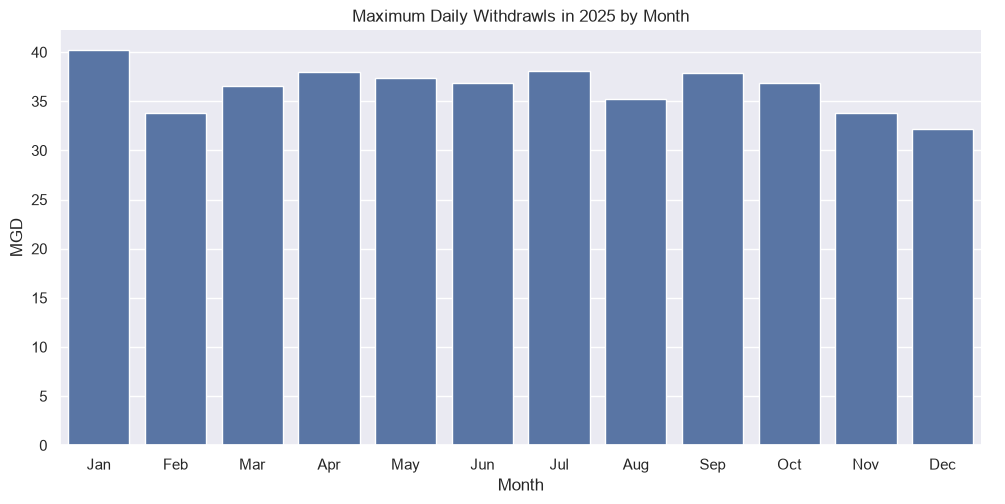

In [34]:
# 2.4 Plot the data
g = sns.catplot(data= df_2025,
                 y = 'MGD',
                x = 'month_abb',
                kind ='bar',
                aspect = 2,
                errorbar= 'ci'
                ).set(title = 'Maximum Daily Withdrawls in 2025 by Month',
                      xlabel = 'Month'
                      )

## 3. Automating the Scraping Process
### 3.1 Construct the scraping function
Note that the PWSID and the year appear in the web address for the page we scraped. Construct a function with two inputs, "PWSID" and "year", that:
  - Creates a URL pointing to the LWSP for that PWSID for the given year
  - Creates a website object and scrapes the data from that object (just as you did above)
  - Constructs a dataframe from the scraped data, mostly as you did above, but includes the PWSID and year provided as function inputs in the dataframe. 
  - Returns the dataframe as the function's output

In [35]:
# 3.1 Create a scraping function
def scraping(the_year , PWSID):
    base_url = f'https://www.ncwater.org/WUDC/app/LWSP/report.php?pwsid={PWSID}&year={the_year}'

    response = requests.get(base_url)
    the_website = BeautifulSoup(response.text,'html.parser')

    name = the_website.select_one('td tr:nth-child(1) td:nth-child(2)').get_text(strip=True) 
    contact = the_website.select_one('tr:nth-child(4) td:nth-child(2)').get_text(strip=True) 
    ownership = the_website.select_one('tr:nth-child(2) td:nth-child(4)').get_text(strip=True) 
    mgd = [items.get_text(strip=True) for items in the_website.select('th~ td+ td')]
    month_order = [1,5,9,2,6,10,3,7,11,4,8,12]

    df = pd.DataFrame({
        "water system name" : name,
        "ownership" : ownership,
        'contact' : contact,
        'MGD': mgd,
        'month' : month_order,
        'year' : the_year
        }).sort_values(by = 'month')

    df['date'] = pd.to_datetime({
        'year' : df['year'],
        'month' : df['month'],
        'day' : 1 })
    df['month_abb'] = pd.Categorical(
    values =df['date'].dt.month_name().str[:3],
    categories =calendar.month_abbr[1:])
    
    df['MGD'] = df['MGD'].astype('float')
    return df

df_2024 = scraping(2024,'03-32-010')

df_2024.head()

,water system name,ownership,contact,MGD,month,year,date,month_abb
0,Durham,Municipality,Kieu Tran,34.50,1,2024,2024-01-01,Jan
3,Durham,Municipality,Kieu Tran,32.10,2,2024,2024-02-01,Feb
6,Durham,Municipality,Kieu Tran,38.20,3,2024,2024-03-01,Mar
9,Durham,Municipality,Kieu Tran,36.73,4,2024,2024-04-01,Apr
1,Durham,Municipality,Kieu Tran,36.06,5,2024,2024-05-01,May


### 3.2 Fetch and plot data for Durham (PWSID=`03-32-010`) in 2020
* Use the function above to extract and plot max daily withdrawals for Durham (PWSID=`03-32-010`) for each month in 2020.
* Reveal the structure of your dataframe using the `info()` function. 
* Then create plot your data in a line plot as above: Max Usage by Month.

In [40]:
# 3.2.1 Scrape data for 03-32-010 in 2020 & display its structure
durham_2020 = scraping(2020,'03-32-010')

durham_2020.info()

<class 'pandas.DataFrame'>
Index: 12 entries, 0 to 11
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   water system name  12 non-null     str           
 1   ownership          12 non-null     str           
 2   contact            12 non-null     str           
 3   MGD                12 non-null     float64       
 4   month              12 non-null     int64         
 5   year               12 non-null     int64         
 6   date               12 non-null     datetime64[us]
 7   month_abb          12 non-null     category      
dtypes: category(1), datetime64[us](1), float64(1), int64(2), str(3)
memory usage: 1.1 KB


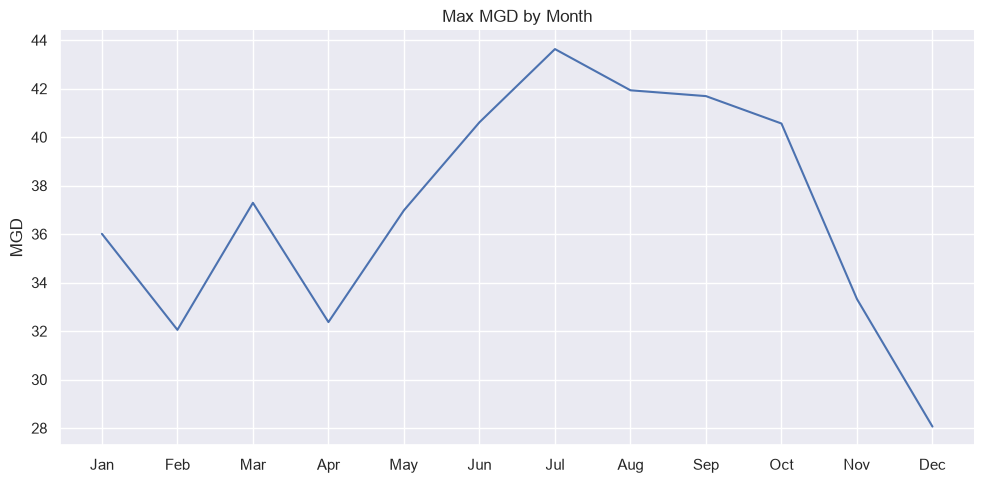

In [41]:
# 3.2.2 Plot the data
g = sns.relplot(data = durham_2020,
                kind = 'line',
                x= 'month_abb',
                y = 'MGD',
                aspect = 2).set(title = "Max MGD by Month",
                               xlabel = '')

### 3.3 Fetch and plot data for Cary (PWSID=`03-92-020`) in 2020

In [37]:
# 3.3.1 Fetch and plot data for Cary (PWSID=`03-92-020`) in 2020
cary_2020 = scraping(2020, '03-92-020')
cary_2020.info()

<class 'pandas.DataFrame'>
Index: 12 entries, 0 to 11
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   water system name  12 non-null     str           
 1   ownership          12 non-null     str           
 2   contact            12 non-null     str           
 3   MGD                12 non-null     float64       
 4   month              12 non-null     int64         
 5   year               12 non-null     int64         
 6   date               12 non-null     datetime64[us]
 7   month_abb          12 non-null     category      
dtypes: category(1), datetime64[us](1), float64(1), int64(2), str(3)
memory usage: 1.1 KB


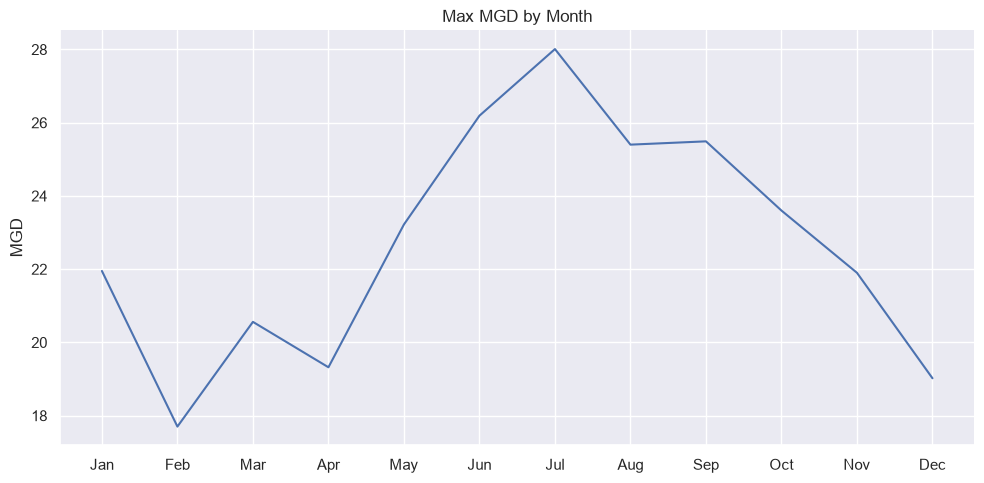

In [38]:
# 3.3.2 Plot the Cary data
g = sns.relplot(data = cary_2020,
                kind = 'line',
                x= 'month_abb',
                y = 'MGD',
                aspect = 2).set(title = "Max MGD by Month",
                               xlabel= '')

### 3.4 Examine monthy max discharge from 2020-2025
* Use list comprehension (or other methods) to produce a list of dataframes, one for each year in 2020 to 2025
* Concatenate these dataframes into a single one including data for all years
* Create a line plot of max monthly discharge across the full timespan (x-axis labels do not have to be months)

In [12]:
# 3.4.1 Generate a list of the dataframes
df_list = [scraping(2020,'03-32-010'),scraping(2021,'03-32-010'),scraping(2022,'03-32-010'),scraping(2023,'03-32-010'),scraping(2024,'03-32-010'),scraping(2025,'03-32-010')]

# 3.4.2 Combine them into a single dataframe

df_2020_2025 = pd.concat(df_list, ignore_index=True)

df_2020_2025.info()


<class 'pandas.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   water system name  72 non-null     str           
 1   ownership          72 non-null     str           
 2   contact            72 non-null     str           
 3   MGD                72 non-null     float64       
 4   month              72 non-null     int64         
 5   year               72 non-null     int64         
 6   date               72 non-null     datetime64[us]
dtypes: datetime64[us](1), float64(1), int64(2), str(3)
memory usage: 4.1 KB


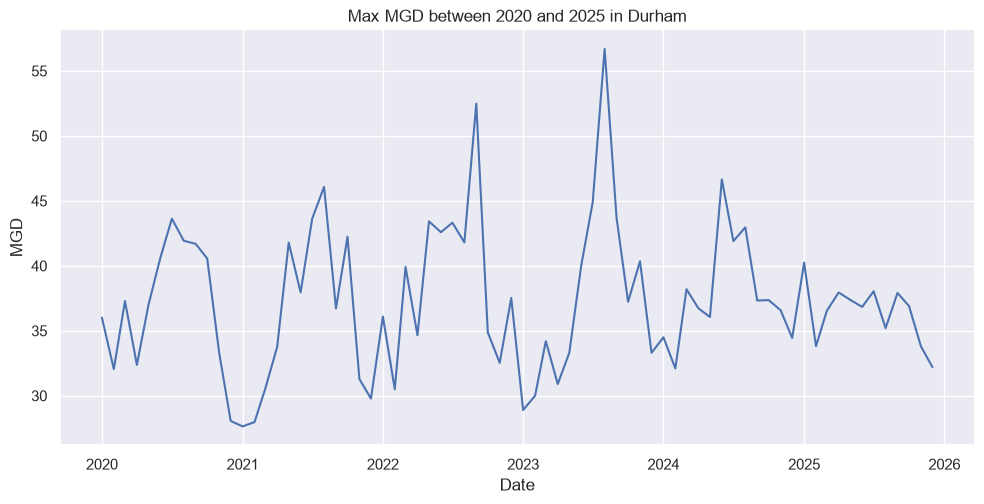

In [14]:
# 3.4.3 Plot
g = sns.relplot(data = df_2020_2025,
                kind = 'line',
                x = 'date',
                y = 'MGD',
                aspect = 2).set(title = "Max MGD between 2020 and 2025 in Durham",
                               xlabel = 'Date')